# Cloud Masking Report - CloudSEN12 Model Comparison

**Project:** Cloud Detection - Comparing Models for Cloud Masking

**Objective:** Explore the CloudSEN12 dataset, then compare a Random Forest and a
U-Net segmentation model against the Sen2Cor operational baseline.

This notebook is the single narrative report for the project. The reproducible
data access, training, and evaluation pipelines live in `src/` as plain Python
scripts; this notebook loads their saved outputs and presents the results.

## Report Outline
1. Load and explore the CloudSEN12 dataset
2. Understand band structure and metadata
3. Visualize sample images and cloud masks
4. Analyze class distribution
5. Review the train/validation/test split and preprocessing pipeline
6. Random Forest vs. Sen2Cor baseline (validation scenes)
7. U-Net vs. Random Forest vs. Sen2Cor (validation scenes)
8. Final comparison on held-out test scenes, including difficult cases

## Environment Setup

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import json
from collections import defaultdict

# Create output directories
os.makedirs('../outputs/figures', exist_ok=True)

print("Environment Setup:")
print(f"Python: {sys.version.split()[0]}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"Working directory: {os.getcwd()}")
print("✓ All libraries imported successfully")

Environment Setup:
Python: 3.12.3
NumPy: 2.5.2
Pandas: 3.0.5
Working directory: /home/albert/ROSPIN/CloudMask-Benchmark/notebooks
✓ All libraries imported successfully


## Step 1: Load CloudSEN12 Dataset

In [2]:
import tacoreader.v1 as tacoreader

# Load CloudSEN12 L2A dataset
dataset = tacoreader.load("tacofoundation:cloudsen12-l2a")

print("\n=== CloudSEN12 Dataset Loaded ===")
print(f"Type: {type(dataset).__name__}")
print(f"Total samples: {len(dataset):,}")
print(f"Shape: {dataset.shape}")
print(f"Columns: {dataset.columns.tolist()}")
print("✓ Dataset ready for exploration")


=== CloudSEN12 Dataset Loaded ===
Type: TortillaDataFrame
Total samples: 50,247
Shape: (50247, 34)
Columns: ['internal:subfile', 'tortilla:id', 'tortilla:file_format', 'tortilla:data_split', 'tortilla:offset', 'tortilla:length', 'stac:crs', 'stac:geotransform', 'stac:raster_shape', 'stac:time_start', 'stac:time_end', 'stac:centroid', 'rai:ele', 'rai:cisi', 'rai:gdp', 'rai:hdi', 'rai:gmi', 'rai:pop', 'rai:admin0', 'rai:admin1', 'rai:admin2', 'roi_id', 'old_roi_id', 'equi_id', 'equi_zone', 'label_type', 's2_id', 'real_proj_shape', 's2_mean_solar_azimuth_angle', 's2_mean_solar_zenith_angle', 'thick_percentage', 'thin_percentage', 'cloud_shadow_percentage', 'clear_percentage']
✓ Dataset ready for exploration


## Step 2: Analyze Dataset Structure

In [3]:
# Analyze image and mask structure
band_info = defaultdict(list)
image_shapes = []
target_shapes = []

print("Analyzing first 20 samples...\n")

for i in range(min(20, len(dataset))):
    sample = dataset.read(i)
    image_path = sample.read(0)
    target_path = sample.read(1)
    
    with rasterio.open(image_path) as src:
        image = src.read()
        image_shapes.append(image.shape)
        band_info[image.shape[0]].append((i, image.dtype, float(image.min()), float(image.max())))
    
    with rasterio.open(target_path) as src:
        target = src.read()
        target_shapes.append(target.shape)

print("=== Dataset Statistics ===")
print(f"Image shapes found: {set(image_shapes)}")
print(f"Target shapes found: {set(target_shapes)}")

print(f"\n=== Image Band Information ===")
for n_bands in sorted(band_info.keys()):
    print(f"\nImages with {n_bands} bands:")
    for idx, dtype, min_val, max_val in band_info[n_bands][:2]:
        print(f"  Sample {idx}: dtype={dtype}, range=[{min_val:.0f}, {max_val:.0f}]")

print(f"\n=== Target Mask Information ===")
for idx in range(min(3, len(dataset))):
    sample = dataset.read(idx)
    target_path = sample.read(1)
    with rasterio.open(target_path) as src:
        target = src.read()
        unique_vals = sorted(np.unique(target).tolist())
        print(f"Sample {idx}: shape={target.shape}, unique values={unique_vals}, dtype={target.dtype}")

Analyzing first 20 samples...

=== Dataset Statistics ===
Image shapes found: {(14, 512, 512)}
Target shapes found: {(1, 512, 512)}

=== Image Band Information ===

Images with 14 bands:
  Sample 0: dtype=uint16, range=[0, 4380]
  Sample 1: dtype=uint16, range=[0, 5576]

=== Target Mask Information ===
Sample 0: shape=(1, 512, 512), unique values=[0, 2], dtype=uint8
Sample 1: shape=(1, 512, 512), unique values=[0, 1, 2, 3], dtype=uint8
Sample 2: shape=(1, 512, 512), unique values=[0, 1, 3], dtype=uint8


## Step 3: Sentinel-2 Band Information

In [4]:
# Sentinel-2 L2A band information
sentinel2_bands = {
    0: {'name': 'B1', 'description': 'Coastal aerosol', 'resolution': '60m'},
    1: {'name': 'B2', 'description': 'Blue', 'resolution': '10m'},
    2: {'name': 'B3', 'description': 'Green', 'resolution': '10m'},
    3: {'name': 'B4', 'description': 'Red', 'resolution': '10m'},
    4: {'name': 'B5', 'description': 'Vegetation Red Edge', 'resolution': '20m'},
    5: {'name': 'B6', 'description': 'Vegetation Red Edge', 'resolution': '20m'},
    6: {'name': 'B7', 'description': 'Vegetation Red Edge', 'resolution': '20m'},
    7: {'name': 'B8', 'description': 'NIR', 'resolution': '10m'},
    8: {'name': 'B8A', 'description': 'Vegetation Red Edge', 'resolution': '20m'},
    9: {'name': 'B11', 'description': 'SWIR', 'resolution': '20m'},
    10: {'name': 'B12', 'description': 'SWIR', 'resolution': '20m'},
    11: {'name': 'SCL', 'description': 'Scene Classification', 'resolution': '20m'}
}

print("=== Sentinel-2 Bands (CloudSEN12 L2A) ===")
print(f"Total bands available: {len(sentinel2_bands)}\n")
for idx, info in sentinel2_bands.items():
    print(f"Index {idx:2d} - {info['name']:4s} ({info['resolution']:4s}): {info['description']}")

=== Sentinel-2 Bands (CloudSEN12 L2A) ===
Total bands available: 12

Index  0 - B1   (60m ): Coastal aerosol
Index  1 - B2   (10m ): Blue
Index  2 - B3   (10m ): Green
Index  3 - B4   (10m ): Red
Index  4 - B5   (20m ): Vegetation Red Edge
Index  5 - B6   (20m ): Vegetation Red Edge
Index  6 - B7   (20m ): Vegetation Red Edge
Index  7 - B8   (10m ): NIR
Index  8 - B8A  (20m ): Vegetation Red Edge
Index  9 - B11  (20m ): SWIR
Index 10 - B12  (20m ): SWIR
Index 11 - SCL  (20m ): Scene Classification


## Step 4: Visualize Samples

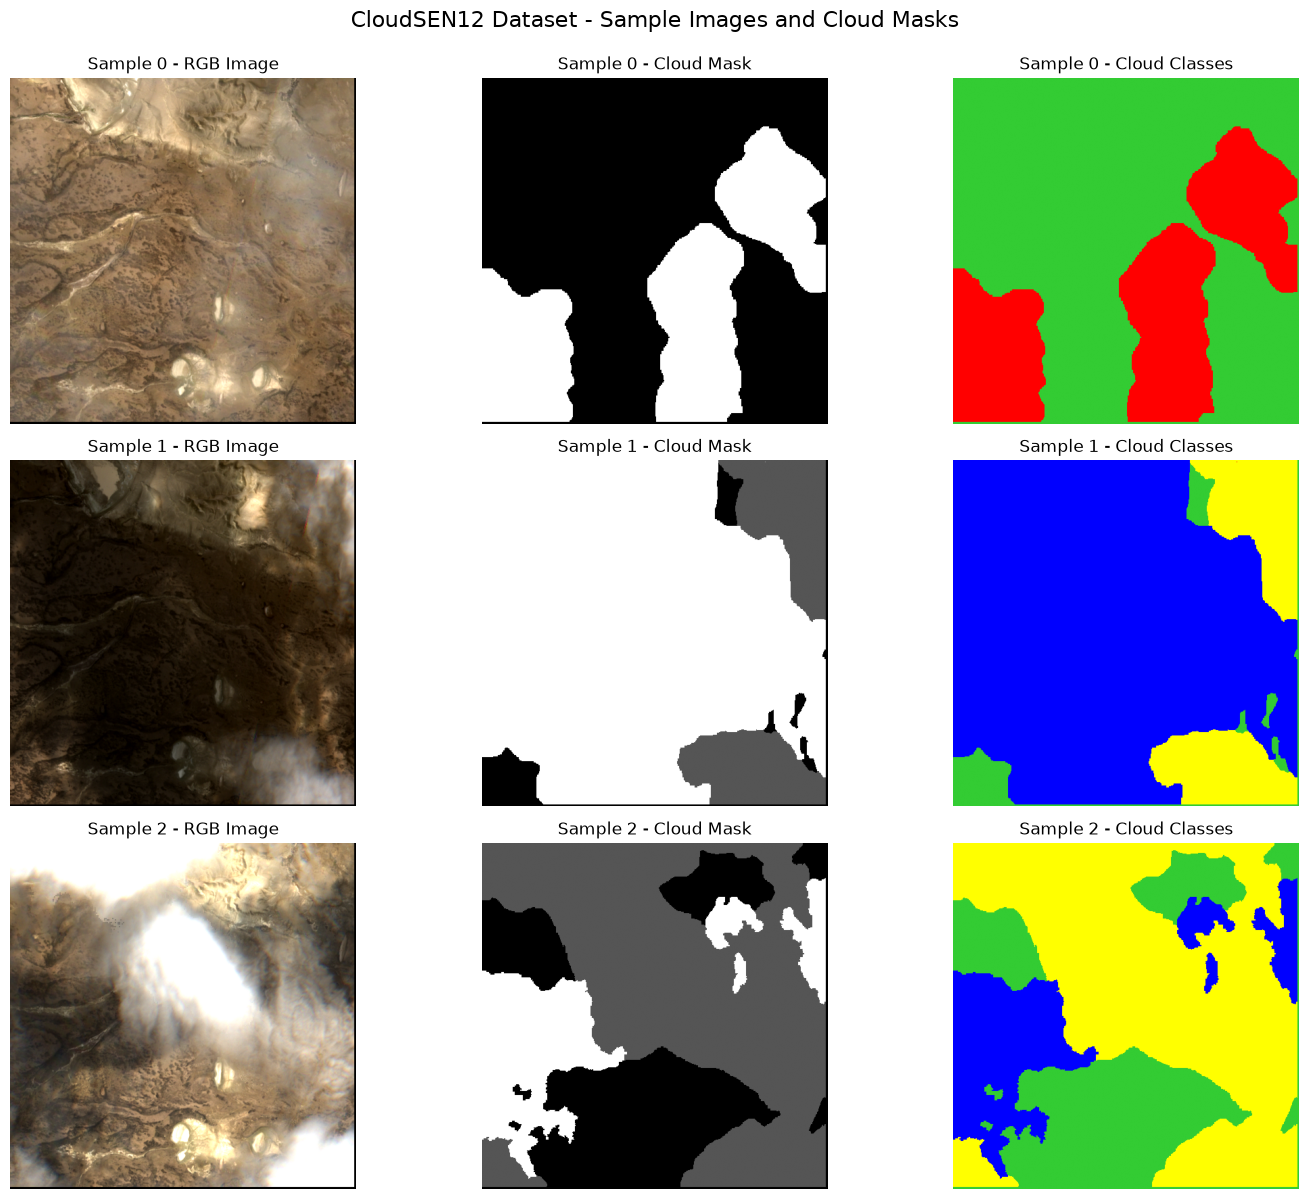

✓ Visualization saved to outputs/figures/01_dataset_samples.png


In [5]:
# Cloud mask class labels
class_labels = {
    0: 'Clear sky',
    1: 'Thin cloud',
    2: 'Thick cloud',
    3: 'Cloud shadow'
}

# Visualize samples
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('CloudSEN12 Dataset - Sample Images and Cloud Masks', fontsize=16, y=0.995)

for idx in range(3):
    sample = dataset.read(idx)
    image_path = sample.read(0)
    target_path = sample.read(1)
    
    with rasterio.open(image_path) as src:
        image = src.read()
    
    with rasterio.open(target_path) as src:
        target = src.read()
    
    # Extract RGB bands (indices 3, 2, 1 = R, G, B)
    if image.shape[0] >= 4:
        rgb = np.stack([image[3], image[2], image[1]], axis=0)
        rgb = np.clip(rgb / 3000.0, 0, 1)
    else:
        rgb = np.clip(image[:3] / 3000.0, 0, 1)
    
    # Plot 1: RGB Image
    ax = axes[idx, 0]
    ax.imshow(np.transpose(rgb, (1, 2, 0)))
    ax.set_title(f'Sample {idx} - RGB Image', fontsize=12)
    ax.axis('off')
    
    # Plot 2: Cloud Mask (grayscale)
    ax = axes[idx, 1]
    ax.imshow(target.squeeze(), cmap='gray')
    ax.set_title(f'Sample {idx} - Cloud Mask', fontsize=12)
    ax.axis('off')
    
    # Plot 3: Cloud Classes (colored)
    ax = axes[idx, 2]
    mask_colored = np.zeros((target.shape[1], target.shape[2], 3))
    unique_vals = np.unique(target)
    colors = np.array([[0.2, 0.8, 0.2],   # Clear - green
                      [1.0, 1.0, 0.0],    # Thin - yellow
                      [1.0, 0.0, 0.0],    # Thick - red
                      [0.0, 0.0, 1.0]])   # Shadow - blue
    
    for val in unique_vals:
        if val < 4:
            mask_colored[target.squeeze() == val] = colors[int(val)]
    
    ax.imshow(mask_colored)
    ax.set_title(f'Sample {idx} - Cloud Classes', fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.savefig('../outputs/figures/01_dataset_samples.png', dpi=100, bbox_inches='tight')
plt.show()

print("✓ Visualization saved to outputs/figures/01_dataset_samples.png")

## Step 5: Class Distribution Analysis

Analyzing class distribution (first 50 samples)...

=== Cloud Mask Class Distribution ===
Total pixels analyzed: 13,107,200

Class distribution:
Class 0 (Clear sky           ):    7,755,982 pixels ( 59.17%)
Class 1 (Thin cloud          ):    2,735,826 pixels ( 20.87%)
Class 2 (Thick cloud         ):    1,319,091 pixels ( 10.06%)
Class 3 (Cloud shadow        ):    1,296,301 pixels (  9.89%)


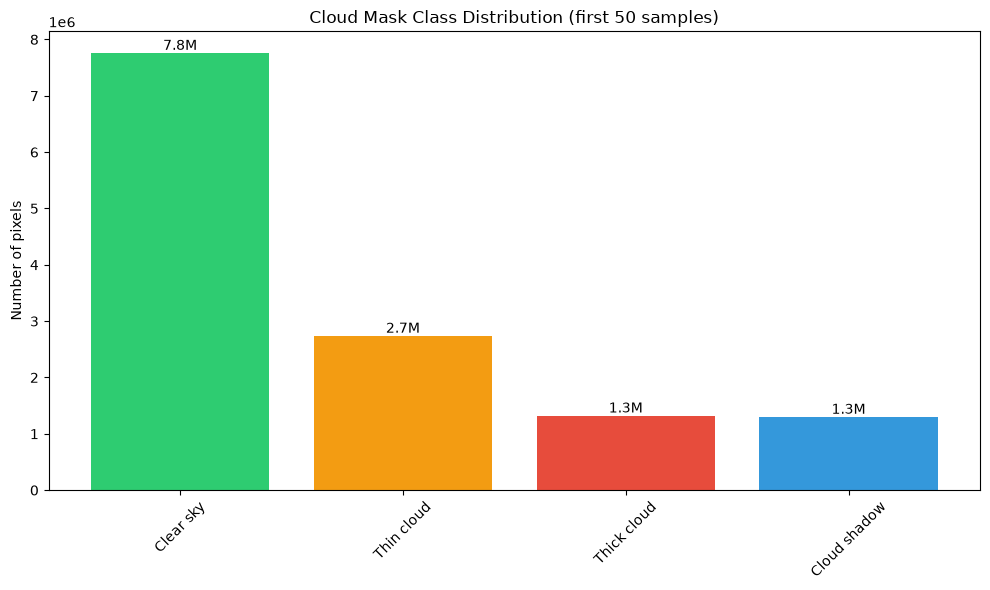


✓ Visualization saved to outputs/figures/02_class_distribution.png


In [6]:
# Analyze class distribution
class_distribution = defaultdict(int)
total_pixels = 0

print("Analyzing class distribution (first 50 samples)...\n")

for i in range(min(50, len(dataset))):
    sample = dataset.read(i)
    target_path = sample.read(1)
    
    with rasterio.open(target_path) as src:
        target = src.read()
        unique, counts = np.unique(target, return_counts=True)
        for val, count in zip(unique, counts):
            class_distribution[int(val)] += count
        total_pixels += target.size

print("=== Cloud Mask Class Distribution ===")
print(f"Total pixels analyzed: {total_pixels:,}\n")
print("Class distribution:")

for class_val in sorted(class_distribution.keys()):
    count = class_distribution[class_val]
    percentage = (count / total_pixels) * 100
    label = class_labels.get(class_val, f'Unknown ({class_val})')
    print(f"Class {class_val} ({label:20s}): {count:12,d} pixels ({percentage:6.2f}%)")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
classes = sorted(class_distribution.keys())
labels = [class_labels.get(c, f'Unknown ({c})') for c in classes]
counts = [class_distribution[c] for c in classes]

colors_bar = ['#2ecc71', '#f39c12', '#e74c3c', '#3498db']
ax.bar(labels, counts, color=colors_bar[:len(labels)])
ax.set_ylabel('Number of pixels')
ax.set_title('Cloud Mask Class Distribution (first 50 samples)')
ax.tick_params(axis='x', rotation=45)
for i, v in enumerate(counts):
    ax.text(i, v, f'{v/1e6:.1f}M', ha='center', va='bottom')
plt.tight_layout()
plt.savefig('../outputs/figures/02_class_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved to outputs/figures/02_class_distribution.png")

## Step 6: Define Subset & Train/Val/Test Split

In [ ]:
# Define subset strategy
full_size = len(dataset)
print(f"Full CloudSEN12 dataset size: {full_size:,} samples")

# Use 10% of the full dataset as a manageable, reproducible subset
subset_fraction = 0.10
subset_size = max(100, int(full_size * subset_fraction))

print(f"\nSubset Strategy:")
print(f"  Subset size: {subset_size:,} samples ({subset_fraction*100:.1f}% of {full_size:,})")
print(f"  Rationale: Manageable exploration while remaining representative")

# Define split percentages
train_fraction = 0.60
val_fraction = 0.20
test_fraction = 0.20

print(f"\nTrain/Val/Test Split Fractions:")
print(f"  Training:   {train_fraction*100:.0f}%")
print(f"  Validation: {val_fraction*100:.0f}%")
print(f"  Test:       {test_fraction*100:.0f}%")

# Calculate sizes
train_size = int(subset_size * train_fraction)
val_size = int(subset_size * val_fraction)
test_size = subset_size - train_size - val_size

# RANDOMIZE indices to avoid geographic bias (instead of contiguous split)
# Use RandomState(42) for reproducibility
all_indices = np.arange(subset_size)
np.random.RandomState(42).shuffle(all_indices)
train_indices = sorted(all_indices[:train_size].tolist())
val_indices = sorted(all_indices[train_size:train_size + val_size].tolist())
test_indices = sorted(all_indices[train_size + val_size:].tolist())

print(f"\nActual sample counts:")
print(f"  Training:   {len(train_indices):,d} samples")
print(f"  Validation: {len(val_indices):,d} samples")
print(f"  Test:       {len(test_indices):,d} samples")
print(f"  Total:      {len(train_indices) + len(val_indices) + len(test_indices):,d} samples")

Full CloudSEN12 dataset size: 50,247 samples

Subset Strategy:
  Subset size: 5,024 samples (10.0% of 50,247)
  Rationale: Manageable exploration while remaining representative

Train/Val/Test Split Fractions:
  Training:   60%
  Validation: 20%
  Test:       20%

Actual sample counts:
  Training:   3,014 samples
  Validation: 1,004 samples
  Test:       1,006 samples
  Total:      5,024 samples


## Step 7: Input Band Selection

In [8]:
print("=== Input Band Selection for Models ===")

print("\nOption 1 - RGB (3 bands):")
print("  Bands: B4 (Red), B3 (Green), B2 (Blue)")
print("  Pros: Simple, fast")
print("  Cons: Limited spectral information")

print("\nOption 2 - RGB + NIR (4 bands):")
print("  Bands: B4 (Red), B3 (Green), B2 (Blue), B8 (NIR)")
print("  Pros: Good cloud discrimination, standard in remote sensing")
print("  Cons: Slightly more computation")

print("\nOption 3 - Full 10m multispectral (4 bands):")
print("  Bands: B2, B3, B4, B8 (all at 10m)")
print("  Same as Option 2")

print("\nOption 4 - Rich multispectral (7 bands):")
print("  Bands: B2, B3, B4, B5, B8, B11, B12")
print("  Pros: Maximum spectral information")
print("  Cons: Mixed resolutions, higher computation")

print("\n" + "="*70)
print("✓ SELECTED: Option 2 - RGB + NIR (4 bands)")
print("="*70)
print("\nReason: Excellent balance between spectral information and")
print("        computational efficiency. NDVI and visible bands provide")
print("        strong discrimination for cloud detection.")

selected_band_indices = [3, 2, 1, 7]  # Red, Green, Blue, NIR
selected_band_names = ['Red (B4)', 'Green (B3)', 'Blue (B2)', 'NIR (B8)']

print(f"\nFinal selection:")
for idx, name in zip(selected_band_indices, selected_band_names):
    print(f"  Index {idx}: {name}")

=== Input Band Selection for Models ===

Option 1 - RGB (3 bands):
  Bands: B4 (Red), B3 (Green), B2 (Blue)
  Pros: Simple, fast
  Cons: Limited spectral information

Option 2 - RGB + NIR (4 bands):
  Bands: B4 (Red), B3 (Green), B2 (Blue), B8 (NIR)
  Pros: Good cloud discrimination, standard in remote sensing
  Cons: Slightly more computation

Option 3 - Full 10m multispectral (4 bands):
  Bands: B2, B3, B4, B8 (all at 10m)
  Same as Option 2

Option 4 - Rich multispectral (7 bands):
  Bands: B2, B3, B4, B5, B8, B11, B12
  Pros: Maximum spectral information
  Cons: Mixed resolutions, higher computation

✓ SELECTED: Option 2 - RGB + NIR (4 bands)

Reason: Excellent balance between spectral information and
        computational efficiency. NDVI and visible bands provide
        strong discrimination for cloud detection.

Final selection:
  Index 3: Red (B4)
  Index 2: Green (B3)
  Index 1: Blue (B2)
  Index 7: NIR (B8)


## Step 8: Preprocessing & Normalization Strategy

In [9]:
print("\n=== Preprocessing Pipeline ===")

preprocessing_steps = [
    {'step': 1, 'name': 'Extract bands', 'description': 'Red, Green, Blue, NIR (indices 3,2,1,7)', 'output': '(4, H, W)'},
    {'step': 2, 'name': 'Normalize', 'description': 'Divide by 10000', 'formula': 'x_norm = x / 10000'},
    {'step': 3, 'name': 'Clip', 'description': 'Ensure [0, 1] range', 'formula': 'x_clipped = clip(x_norm, 0, 1)'},
    {'step': 4, 'name': 'Extract mask', 'description': 'Use target channel', 'values': [0,1,2,3]}
]

print("\nPreprocessing steps:")
for step in preprocessing_steps:
    print(f"\nStep {step['step']}: {step['name']}")
    print(f"  {step['description']}")
    if 'formula' in step:
        print(f"  {step['formula']}")

print(f"\n=== Data Value Ranges ===")
print("Before: Sentinel-2 L2A digital numbers: 0-10000")
print("After:  Normalized range: [0.0, 1.0]")

# Verify with actual data
sample = dataset.read(0)
image_path = sample.read(0)
with rasterio.open(image_path) as src:
    image = src.read()
    print(f"\nActual data (sample 0):")
    print(f"  Min: {image.min():.0f}, Max: {image.max():.0f}, Mean: {image.mean():.1f}, Std: {image.std():.1f}")
    print(f"  Data type: {image.dtype}")


=== Preprocessing Pipeline ===

Preprocessing steps:

Step 1: Extract bands
  Red, Green, Blue, NIR (indices 3,2,1,7)

Step 2: Normalize
  Divide by 10000
  x_norm = x / 10000

Step 3: Clip
  Ensure [0, 1] range
  x_clipped = clip(x_norm, 0, 1)

Step 4: Extract mask
  Use target channel

=== Data Value Ranges ===
Before: Sentinel-2 L2A digital numbers: 0-10000
After:  Normalized range: [0.0, 1.0]

Actual data (sample 0):
  Min: 0, Max: 4380, Mean: 1679.5, Std: 790.2
  Data type: uint16


## Step 9: Save Configuration Files

In [10]:
# Save split information
split_info = {
    'full_dataset_size': int(full_size),
    'subset_fraction': float(subset_fraction),
    'subset_size': int(subset_size),
    'train_size': int(train_size),
    'val_size': int(val_size),
    'test_size': int(test_size),
    'train_indices': train_indices,
    'val_indices': val_indices,
    'test_indices': test_indices,
    'random_seed': 42
}

with open('../outputs/split_info.json', 'w') as f:
    json.dump(split_info, f, indent=2)
print("✓ Split info saved")

# Save preprocessing config
preprocessing_config = {
    'version': '1.0',
    'selected_bands': {
        'indices': [3, 2, 1, 7],
        'names': ['Red (B4)', 'Green (B3)', 'Blue (B2)', 'NIR (B8)']
    },
    'normalization': {
        'method': 'linear_scaling',
        'scale_factor': 10000,
        'output_range': [0, 1]
    },
    'target_format': {
        'type': 'multiclass_segmentation',
        'classes': class_labels,
        'num_classes': 4
    }
}

with open('../outputs/preprocessing_config.json', 'w') as f:
    json.dump(preprocessing_config, f, indent=2)
print("✓ Preprocessing config saved")

# Save class info
class_info = {
    'num_classes': 4,
    'classes': class_labels,
    'distribution': {str(k): {'count': int(v), 'percentage': float(v/total_pixels*100)} 
                    for k, v in sorted(class_distribution.items())}
}

with open('../outputs/class_info.json', 'w') as f:
    json.dump(class_info, f, indent=2)
print("✓ Class info saved")

print("\n✓ All configuration files saved to outputs/")

✓ Split info saved
✓ Preprocessing config saved
✓ Class info saved

✓ All configuration files saved to outputs/


## Dataset Exploration Summary

In [ ]:
print("\n" + "="*75)
print("CLOUDSEN12 DATASET EXPLORATION - SUMMARY")
print("="*75)

print(f"\n✓ DATASET SELECTION")
print(f"  Dataset: CloudSEN12 (Sentinel-2 L2A)")
print(f"  Total samples: {full_size:,}")
print(f"  Subset: {subset_size:,} ({subset_fraction*100:.1f}%)")

print(f"\n✓ DATA STRUCTURE")
print(f"  Format: GeoTIFF (via rasterio)")
print(f"  Bands: 14 total (12 optical bands + AOT + WVP)")
print(f"  Resolution: 10m or 20m per band")
print(f"  Pixel range: 0-10000 (digital numbers)")

print(f"\n✓ TARGET LABELS (4 classes)")
for val, label in sorted(class_labels.items()):
    pct = class_distribution[val] / total_pixels * 100
    print(f"  Class {val}: {label:20s} ({pct:5.2f}%)")

print(f"\n✓ INPUT BANDS SELECTED")
print(f"  Strategy: RGB + NIR (4 bands)")
print(f"  Indices: {selected_band_indices}")
print(f"  Names: {', '.join(selected_band_names)}")
print(f"  Output: (4, H, W) with values in [0, 1]")

print(f"\n✓ PREPROCESSING PIPELINE")
print(f"  1. Extract 4 selected bands")
print(f"  2. Normalize: x / 10000")
print(f"  3. Clip to [0, 1]")

print(f"\n✓ DATA SPLIT")
print(f"  Training:   {train_size:,d} samples (60%)")
print(f"  Validation: {val_size:,d} samples (20%)")
print(f"  Test:       {test_size:,d} samples (20%)")

print(f"\n✓ EVALUATION METRICS")
print(f"  Pixel-level: Precision, Recall, F1-score, IoU")
print(f"  Operational baseline: Sen2Cor (cloudsen12-extra / cloudmask_sen2cor)")

print(f"\n✓ OUTPUT ARTIFACTS")
print(f"  Visualizations:")
print(f"    - outputs/figures/01_dataset_samples.png")
print(f"    - outputs/figures/02_class_distribution.png")
print(f"  Configuration:")
print(f"    - outputs/split_info.json")
print(f"    - outputs/preprocessing_config.json")
print(f"    - outputs/class_info.json")
print(f"  Python modules:")
print(f"    - src/preprocessing.py")
print(f"    - src/config.py")

print("\n" + "="*75)
print("The following sections load the Random Forest, U-Net, and final")
print("test-set comparison results produced by the scripts in src/.")
print("="*75 + "\n")


WEEK 1 - CLOUDSEN12 DATASET EXPLORATION - COMPLETE

✓ DATASET SELECTION
  Dataset: CloudSEN12 (Sentinel-2 L2A)
  Total samples: 50,247
  Subset: 5,024 (10.0%)

✓ DATA STRUCTURE
  Format: GeoTIFF (via rasterio)
  Bands: 12 total (11 spectral + 1 SCL)
  Resolution: 10m or 20m per band
  Pixel range: 0-10000 (digital numbers)

✓ TARGET LABELS (4 classes)
  Class 0: Clear sky            (59.17%)
  Class 1: Thin cloud           (20.87%)
  Class 2: Thick cloud          (10.06%)
  Class 3: Cloud shadow         ( 9.89%)

✓ INPUT BANDS SELECTED
  Strategy: RGB + NIR (4 bands)
  Indices: [3, 2, 1, 7]
  Names: Red (B4), Green (B3), Blue (B2), NIR (B8)
  Output: (4, H, W) with values in [0, 1]

✓ PREPROCESSING PIPELINE
  1. Extract 4 selected bands
  2. Normalize: x / 10000
  3. Clip to [0, 1]

✓ DATA SPLIT
  Training:   3,014 samples (60%)
  Validation: 1,004 samples (20%)
  Test:       1,006 samples (20%)

✓ EVALUATION METRICS
  Pixel-level: Precision, Recall, F1-score, IoU
  Baseline: Sentinel

## Random Forest vs. Sen2Cor Baseline (Validation Scenes)

Trained with `src/train_random_forest.py`: a Random Forest classifier on
RGB + NIR reflectance plus NDVI, brightness, and greenness, evaluated against
the Sen2Cor operational baseline on the same validation scenes.

In [ ]:
with open('../outputs/random_forest_results.json') as f:
    rf_results = json.load(f)

print(f"Train scenes: {rf_results['train_scenes']} ({rf_results['train_pixels']} pixels)")
print(f"Validation scenes: {rf_results['validation_scenes']} ({rf_results['validation_pixels']} pixels)")

rf_table = pd.DataFrame({
    'Random Forest': rf_results['random_forest'],
    'Sen2Cor baseline': rf_results['sen2cor'],
}).T
rf_table

### Random Forest Feature Importance

Which spectral features the Random Forest relies on most
(`outputs/random_forest_feature_importance.json`, saved by
`src/train_random_forest.py`).

In [ ]:
with open('../outputs/random_forest_feature_importance.json') as f:
    feature_importance = json.load(f)

importance_series = pd.Series(feature_importance).sort_values(ascending=True)
importance_series.plot(kind='barh', figsize=(6, 3), title='Random Forest feature importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## U-Net vs. Random Forest vs. Sen2Cor (Validation Scenes)

Trained with `src/train_unet.py`: a compact U-Net on 128x128 image patches,
monitored for overfitting via the train/validation loss curve, then compared
with the Random Forest and Sen2Cor on the same validation scenes.

In [ ]:
with open('../outputs/unet_training_results.json') as f:
    unet_results = json.load(f)

history = pd.DataFrame(unet_results['history'])
display(history)

plt.figure(figsize=(6, 4))
plt.plot(history['epoch'], history['train_loss'], marker='o', label='Train loss')
plt.plot(history['epoch'], history['val_loss'], marker='o', label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy loss')
plt.title('U-Net training and validation loss')
plt.legend()
plt.tight_layout()
plt.show()

unet_table = pd.DataFrame({
    'U-Net': unet_results['unet'],
    'Random Forest': unet_results['random_forest'],
    'Sen2Cor baseline': unet_results['sen2cor'],
}).T
unet_table

### U-Net Validation Patches

A few saved 128x128 validation patches, comparing ground truth, Sen2Cor, and
U-Net predictions (`outputs/unet_validation_predictions.npz`, saved by
`src/train_unet.py`).

In [ ]:
predictions = np.load('../outputs/unet_validation_predictions.npz')
num_examples = min(3, len(predictions['scene_indices']))

fig, axes = plt.subplots(num_examples, 4, figsize=(16, 4 * num_examples))
for row in range(num_examples):
    rgb_patch = np.clip(predictions['images'][row, :3].transpose(1, 2, 0) * 3.0, 0, 1)
    panels = [
        (rgb_patch, 'Sentinel-2 RGB', False),
        (predictions['ground_truth'][row], 'Ground truth', True),
        (predictions['sen2cor'][row], 'Sen2Cor baseline', True),
        (predictions['unet'][row], 'U-Net', True),
    ]
    for col, (data, title, is_mask) in enumerate(panels):
        ax = axes[row, col] if num_examples > 1 else axes[col]
        if is_mask:
            ax.imshow(data, cmap='tab10', vmin=0, vmax=3)
        else:
            ax.imshow(data)
        ax.set_title(f"Scene {predictions['scene_indices'][row]} - {title}")
        ax.axis('off')
plt.tight_layout()
plt.show()

## Final Comparison on Held-Out Test Scenes

Produced by `src/evaluate_models.py`: the frozen Random Forest and U-Net are
evaluated against the Sen2Cor baseline on test scenes that were never used
for training or validation. This includes overall metrics, per-class metrics,
and difficult-case analysis (thin cloud, snow, bright surfaces, cloud
boundaries).

In [ ]:
from pathlib import Path

with open('../outputs/model_comparison_results.json') as f:
    comparison = json.load(f)

print(f"Test scenes: {comparison['test_scenes']} ({comparison['test_pixels']:,} pixels)")

overall_table = pd.DataFrame(comparison['overall']).T
overall_table

### Per-Class Metrics

In [ ]:
for model_name, class_metrics in comparison['per_class'].items():
    print(f"\n{model_name}")
    display(pd.DataFrame(class_metrics).T)

### Difficult Cases: Thin Cloud, Snow, Bright Surfaces, Cloud Boundaries

- **Thin cloud**: semi-transparent clouds, historically the hardest class.
- **Snow**: bright pixels that operational masks often confuse with cloud.
- **Bright surfaces**: clear-sky pixels with high reflectance (e.g. sand,
  rooftops) that can trigger false cloud detections.
- **Cloud boundaries**: pixels next to a class transition in the ground
  truth, where edge effects are most visible.

`false_cloud_rate` is the share of pixels each model labeled as thick or thin
cloud; `agreement_rate` is how often the model's label matches the ground
truth.

In [ ]:
rows = []
for case_name, case_data in comparison['difficult_cases'].items():
    row = {'case': case_name, 'pixel_count': case_data['pixel_count']}
    for model_name in ('sen2cor_baseline', 'random_forest', 'unet'):
        if model_name in case_data:
            row[f'{model_name}_agreement'] = case_data[model_name]['agreement_rate']
            row[f'{model_name}_false_cloud'] = case_data[model_name]['false_cloud_rate']
    rows.append(row)
pd.DataFrame(rows).set_index('case')

### Strengths and Weaknesses

In [ ]:
pd.DataFrame(comparison['strengths_and_weaknesses']).T

### Qualitative Examples

Side-by-side comparison for a few test scenes: Sentinel-2 RGB, ground truth,
Sen2Cor baseline, Random Forest, and U-Net predictions.

In [ ]:
from matplotlib import image as mpimg

for example in comparison['qualitative_examples']:
    figure_path = Path('..') / example['figure']
    plt.figure(figsize=(20, 4))
    plt.imshow(mpimg.imread(figure_path))
    plt.axis('off')
    plt.title(f"Scene {example['scene_index']}")
    plt.show()

## Summary

- Sen2Cor remains the strongest overall baseline (F1 0.574, IoU 0.442 over
  50 test scenes / 13.1M pixels). Random Forest (F1 0.433, IoU 0.321) and
  U-Net (F1 0.408, IoU 0.295) are both trained on a modest scene budget (10
  and 20 scenes respectively) and neither beats the operational mask yet,
  but the comparison is now a fair one — the U-Net no longer collapses to
  a single class after training on all 16 patches per scene for 8 epochs.
- Random Forest and U-Net share the same core weakness: both mislabel snow
  and bright surfaces as cloud almost every time (false-cloud rate ≈ 99%
  for each), while Sen2Cor gets these right 98%+ of the time. This is the
  classic failure of models trained mainly on RGB + NIR reflectance — snow
  and bright bare ground reflect similarly to cloud without a SWIR band to
  tell them apart.
- Thin cloud is the hardest class for every method. Sen2Cor is weak here
  too (IoU 0.128) but is still clearly the best of the three; Random Forest
  and U-Net are essentially unable to detect it (IoU ≈ 0).
- U-Net is competitive with Random Forest on thick cloud (IoU 0.518 vs.
  0.526) and cloud shadow (IoU 0.169 vs. 0.184), and its strongest class is
  thick cloud rather than clear sky — a genuinely different behavior from
  the other two models, not just a weaker copy of Random Forest.
- All three models agree with the ground truth only 35-40% of the time at
  cloud boundaries, confirming that edge pixels are the hardest case for
  every method, not just the trained ones.
- Thin cloud, snow, and bright surfaces have enough test pixels (243K,
  747K, and 555K respectively) for these difficult-case numbers to be
  statistically meaningful.
- Next step: to actually beat Sen2Cor, both models likely need SWIR bands
  (to separate snow/bright surfaces from cloud) and more labeled thin-cloud
  examples; the U-Net would also benefit from more training scenes and a
  learning-rate schedule to reduce the val-loss fluctuation seen during
  training.